# Heteroscedasticity in Linear Regression

## Objective

The goal of this notebook is to understand heteroscedasticity in Linear Regression and analyze how changing residual variance affects model assumptions.

## What is Heteroscedasticity?

Heteroscedasticity occurs when the variance of residuals is not constant across all prediction values.

In simple words, the spread of errors changes throughout the dataset instead of remaining stable.

## Why is it a Problem?

Heteroscedasticity does not always reduce prediction accuracy significantly, but it can make statistical interpretation less reliable.

It can affect:
- standard errors
- confidence intervals
- hypothesis testing

and make coefficient estimates less trustworthy.

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [41]:
# load dataset
data = pd.read_csv('/content/drive/My Drive/Advertising.csv')
data

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [42]:
# Linear Regression
X = data[['TV', 'Newspaper', 'Radio']]
y = data['Sales']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

from sklearn.linear_model import LinearRegression
lr = LinearRegression()

# train model
lr.fit(x_train, y_train)

LinearRegression()

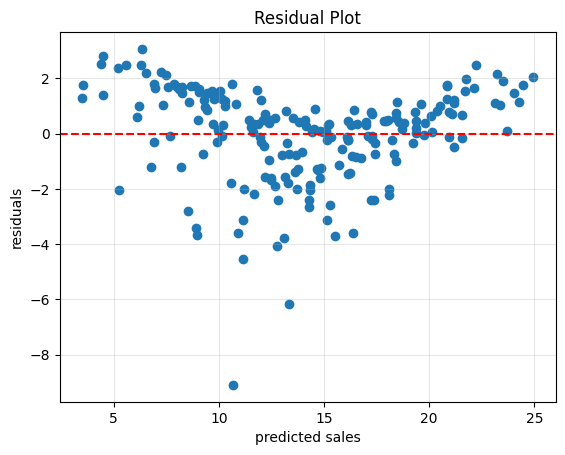

In [43]:
# residual plot
y_pred_full = lr.predict(X)
residuals = y- y_pred_full

plt.scatter(y_pred_full, residuals)
plt.axhline(y=0, color='r', linestyle='--')

plt.title('Residual Plot')
plt.xlabel('predicted sales')
plt.ylabel('residuals')
plt.grid(alpha=0.3)
plt.show()

Here we can observe some visible patterns in the residuals, which suggests that the data may contain slight non-linear relationships.

However, the residual variance appears relatively stable, and no clear funnel-shaped pattern is visible in the plot.

This indicates that strong heteroscedasticity is not present in the dataset.

## Creating Artificial Heteroscedasticity

The original Advertising dataset does not show strong heteroscedasticity.

To study this concept more clearly, additional noise was added to the target variable, where the noise increased with TV advertising spend.

This creates increasing residual variance and produces a funnel-shaped residual pattern.

In [51]:
np.random.seed(42)

# copy
df_hetero = data.copy()

hetero_noise = np.random.normal(
    0,
    df_hetero['TV'] * 0.08
)

df_hetero['Sales_hetero'] = (
    df_hetero['Sales'] + hetero_noise
)

df_hetero

,TV,Radio,Newspaper,Sales,Sales_hetero
0,230.1,37.8,69.2,22.1,31.243514
1,44.5,39.3,45.1,10.4,9.907779
2,17.2,45.9,69.3,9.3,10.191219
3,151.5,41.3,58.5,18.5,36.959122
4,180.8,10.8,58.4,12.9,9.513206
...,...,...,...,...,...
195,38.2,3.7,13.8,7.6,8.777530
196,94.2,4.9,8.1,9.7,3.039250
197,177.0,9.3,6.4,12.8,14.976748
198,283.6,42.0,66.2,25.5,26.820639


In [52]:
X_h = df_hetero[['TV', 'Radio', 'Newspaper']]

y_h = df_hetero['Sales_hetero']

lr = LinearRegression()

lr.fit(X_h, y_h)

LinearRegression()

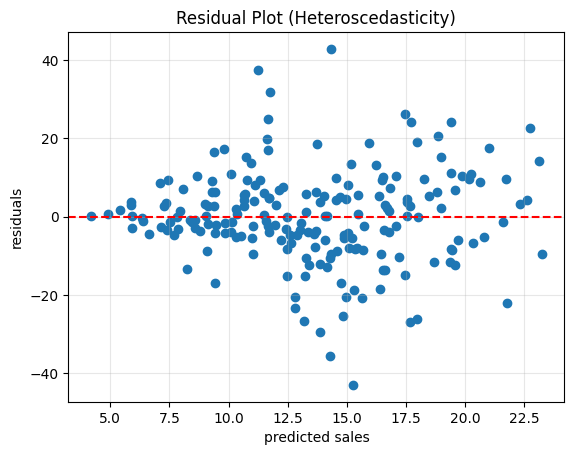

In [53]:
# residual plot
y_pred_h = lr.predict(X_h)
residuals_h = y_h - y_pred_h

plt.scatter(y_pred_h, residuals_h)

plt.axhline(y=0, color='r', linestyle='--')

plt.xlabel("predicted sales")
plt.ylabel("residuals")
plt.title("Residual Plot (Heteroscedasticity)")
plt.grid(alpha=0.3)
plt.show()

## Residual Plot (Heteroscedasticity)

The residual plot shows a visible funnel-shaped pattern where the spread of residuals increases as the predicted sales increase.

This indicates heteroscedasticity, meaning that the variance of residuals is not constant throughout the dataset.

The model errors become larger for higher predicted values, which violates one of the important assumptions of Linear Regression.

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

# independent and dependent variables
X = df_hetero[['TV', 'Radio', 'Newspaper']]
y = df_hetero['Sales_hetero']

# adding constant for statsmodels
X_sm = sm.add_constant(X)

# fitting OLS model
model = sm.OLS(y, X_sm).fit()

# Breusch-Pagan test
bp_test = het_breuschpagan(
    model.resid,
    model.model.exog
)

# p-value
p_value = bp_test[1]
print("Breusch-Pagan p-value:", p_value)


if p_value < 0.05:
    print("Heteroscedasticity detected")
else:
    print("No significant heteroscedasticity detected")

Breusch-Pagan p-value: 6.400594509535539e-05
Heteroscedasticity detected


## Breusch-Pagan Test

The Breusch-Pagan test is used to statistically check for heteroscedasticity.

- Null Hypothesis (H₀): Residual variance is constant.
- Alternative Hypothesis (H₁): Residual variance changes across observations.

A small p-value suggests the presence of heteroscedasticity.

## Applying Log Transformation

A log transformation was applied to the target variable to reduce the increasing variance in residuals.

Log transformation compresses larger values more than smaller values, which helps stabilize the residual spread.

In [ ]:
# log transformation on target variable
df_hetero['Sales_log'] = np.log(df_hetero['Sales_hetero'] - df_hetero['Sales_hetero'].min() + 1)

In [55]:
X = df_hetero[['TV', 'Radio', 'Newspaper']]

y_log = df_hetero['Sales_log']

lr_log = LinearRegression()

lr_log.fit(X, y_log)

y_pred_log = lr_log.predict(X)

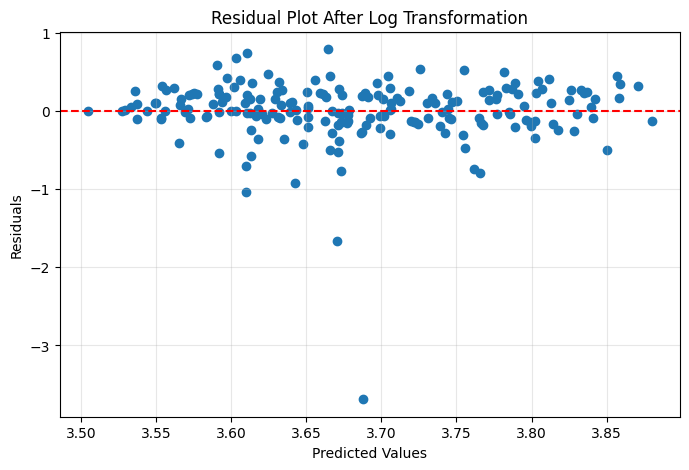

In [ ]:
# residuals after transformation
residuals_log = y_log - y_pred_log

# residual plot
plt.scatter(y_pred_log, residuals_log)
plt.axhline(y=0, color='r', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot After Log Transformation")
plt.grid(alpha=0.3)
plt.show()

## Residual Plot After Log Transformation

After applying log transformation on the target variable, the residual spread becomes more stable across predicted values.

Compared to the earlier funnel-shaped residual pattern, the variance of residuals is now more evenly distributed around zero.

This suggests that the log transformation helped reduce heteroscedasticity and improved the constant variance assumption of Linear Regression.

# Final Comparison

| Aspect | Before Log Transformation | After Log Transformation |
|---|---|---|
| Residual Spread | Increasing | More Stable |
| Funnel Pattern | Clearly Visible | Reduced |
| Variance Stability | Poor | Improved |
| Heteroscedasticity | Stronger | Reduced |

# Final Insight

This notebook demonstrates how heteroscedasticity can violate the constant variance assumption of Linear Regression.

By introducing increasing residual variance into the Advertising dataset, a clear funnel-shaped residual pattern was observed.

After applying log transformation to the target variable, the residual spread became more stable, showing how transformations can help reduce heteroscedasticity and improve model assumptions.